In [1]:
from MLtools import ImageData, SC_Model
from torch.utils.data import DataLoader, random_split
import torch
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from torchvision.transforms import Resize
from matplotlib.patches import Rectangle
import cv2 as cv

from torchvision.io import read_image
import csv

In [2]:
class Reshala:
    def __init__(self, im_area):
        self.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

        self.classifier = None

        self.segmentator = torch.load("SC_model1.pth", weights_only=False).to(self.device)
        self.segmentator.eval()

        self.thermal_size = (62,80)
        self.image_size = (640, 640)
        self.pixel_coef = im_area/(self.image_size[0]*self.image_size[1])
        self.alpha = 0.4

    def _load_img(self, path):
        image = read_image(path)
        
        transform = Resize(self.image_size)
        image = transform(image/255.0)
        image = torch.unsqueeze(image, 0).to(self.device)

        return image.float()

    def _load_heatM(self, path):
        thermal_image = torch.zeros(self.thermal_size, dtype=torch.float32)
        
        with open(path, 'r', encoding='utf-8') as file:
            content = file.read().replace(';', ',')
        
        reader = csv.reader(content.splitlines(), delimiter=',')
        for i, row in enumerate(reader):
            thermal_image[i, :] = torch.tensor(list(map(float, row[3::4])), dtype=torch.float32)

        return thermal_image

    def _segment(self, img):
        feature_map = self.segmentator(img).cpu()
        
        thr_fmap = torch.zeros_like(feature_map)
        thr_fmap[feature_map>0.9] = 1

        return thr_fmap.view(self.image_size)

    def _watershed(self, img, fmap):
        fmap = fmap.cpu().numpy()
        
        kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))

        bin_img = cv.morphologyEx((fmap*255).astype(np.uint8),
                                   cv.MORPH_OPEN,
                                   kernel,
                                   iterations=2)
    
        
        # sure background area
        sure_bg = cv.dilate(bin_img, kernel, iterations=3)
         
        # Distance transform
        dist = cv.distanceTransform(bin_img, cv.DIST_L2, 5)
         
        #foreground area
        ret, sure_fg = cv.threshold(dist, 0.5 * dist.max(), 255, cv.THRESH_BINARY)
        sure_fg = sure_fg.astype(np.uint8)  
         
        # unknown area
        unknown = cv.subtract(sure_bg, sure_fg)

        ret, markers = cv.connectedComponents(sure_fg)
         
        # Add one to all labels so that background is not 0, but 1
        markers += 1
        # mark the region of unknown with zero
        markers[unknown == 255] = 0

        
        np_image = torch.squeeze(img, 0).cpu().numpy()
        np_image = np_image.swapaxes(1,2).swapaxes(0,2)
        
        markers = cv.watershed((np_image*255).astype(np.uint8), markers)

        return markers

    def _detector(self, markers):
        centers = []
        bboxes = []
        p_area = []
        for obj_id in np.unique(markers):
            if obj_id == -1 or obj_id == 1:
                continue
            inds = np.where(markers == obj_id)
        
            y1 = np.min(inds[0]).item()
            x1 = np.min(inds[1]).item()
            y2 = np.max(inds[0]).item()
            x2 = np.max(inds[1]).item()
        
            centers.append([y1+(y2-y1)//2, x1+(x2-x1)//2])
            bboxes.append([y1, x1, y2, x2])
            p_area.append(len(inds[0]))
        
        return np.array(p_area), np.array(bboxes), np.array(centers)

    def _get_heat(self, heat_map, centers):
        transform = Resize(self.image_size)
        up_thermal = transform(heat_map.unsqueeze(0))[0].numpy()

        T = []
        for cent in centers:
            T.append(up_thermal[cent[0],cent[1]])
        return np.array(T)

    # work in progress...
    def _get_label(self, img):
        label = "pear"
        return label

    def draw_result(self, img, bboxes, centers, T, markers, color = None):
        img = torch.squeeze(img, 0).to('cpu').numpy()
        img = img.swapaxes(1,2).swapaxes(0,2)
        
        fig, ax = plt.subplots()
        
        # чертим боксы и температуру
        for rect, cent, t in zip(bboxes, centers, T):
            rectanle = Rectangle((rect[1], rect[0]), rect[3]-rect[1], rect[2]-rect[0], linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rectanle)
            ax.text(cent[1]-20, cent[0]+10, f'{int(t)},{int(10*(t-int(t)))}℃')

        # рисуем маски разных цветов
        for obj_id in np.unique(markers):
            if obj_id == -1 or obj_id == 1:
                continue

            inds = np.where(markers == obj_id)

            if color is None:
                #           уменьшаем старые значения     добавляем нового случайного цвета
                img[markers == obj_id] = (1.0-self.alpha)*img[markers == obj_id] + self.alpha*np.random.random(3)
            else:
                img[markers == obj_id] = (1.0-self.alpha)*img[markers == obj_id] + self.alpha*color


        ax.imshow(img)
        # plt.scatter(centers[:,1], centers[:,0], c='blue', s=100)
        plt.show()

    def __call__(self, name, draw=False):
        img_path   = f"datasets/camera/{name}.jpg"
        therm_path = f"datasets/thermal_csv/{name}.csv"

        img = self._load_img(img_path)
        heat_map = self._load_heatM(therm_path)

        fmap = self._segment(img)

        markers = self._watershed(img, fmap)
        p_area, bboxes, centers = self._detector(markers)

        T = self._get_heat(heat_map, centers)

        label = self._get_label(img)

        if draw:
            self.draw_result(img, bboxes, centers, T, markers)#, np.array([1.0,0.0,0.0]))
            
        return p_area, T, label

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12382688..1.0000002].


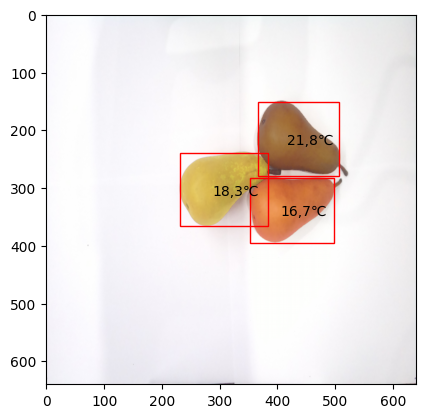

Площади:  [12426 12655 11708]
Температуры:  [21.885246 18.300781 16.755255]
Тип:  pear


In [4]:
table_area = 1627.1
b = Reshala(table_area)

p_area, T, label = b("4", True)
print("Площади: ", p_area)
print("Температуры: ", T)
print("Тип: ", label)